In [1]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder
import openpyxl

In [7]:
df_variables = pd.read_excel('Data/Diccionario_Variables_Alumnos.xlsx')
df_variables.head()

,Variables,Descripción,Valores
0,ID,Identificador único del préstamo.,Código identificador del cliente.
1,Edad,Edad del prestatario.,Valor numérico.
2,Ingresos,Ingreso anual del prestatario.,Valor numérico.
3,Monto_Inicial,Cantidad de dinero acordada.,Valor numérico.
4,Scoring_Crediticio,"La puntuación crediticia del prestatario, que ...",Valor numérico.


In [2]:
df_total=pd.read_csv("Data/df_filtrado.csv")
df_total.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
0,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,...,0.0,0,65.85,0,1,0,0,0,0,1
1,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,...,0.0,0,260.60,0,0,1,0,1,0,0
2,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,...,1.0,0,221.02,0,0,1,0,1,0,0
3,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,...,0.0,0,125.00,0,0,1,0,1,0,0
4,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,...,0.0,0,800.00,0,0,1,0,0,0,1


In [8]:
df_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 101886 entries, 0 to 101885
Data columns (total 23 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   ID                                     101886 non-null  str    
 1   Edad                                   101886 non-null  int64  
 2   Ingresos                               101886 non-null  float64
 3   Monto_Inicial                          101886 non-null  int64  
 4   Scoring_Crediticio                     101886 non-null  int64  
 5   Meses_Empleo                           101886 non-null  float64
 6   Num_Creditos                           101886 non-null  int64  
 7   Ratio_Interes                          101886 non-null  float64
 8   Duracion                               101886 non-null  float64
 9   Ratio_Deuda_Ingresos                   101886 non-null  float64
 10  Estudios                               101886 non-null  int64  
 11

In [9]:
df_total.describe()

,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,...,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero
count,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,...,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000,101886.000000
mean,39.666029,41503.046071,45009.637487,692.303575,212.914974,1.998116,10.670138,37.250574,0.321375,0.929294,...,0.298687,0.115109,384.698908,0.148519,0.099513,0.550056,0.201912,0.511778,0.186424,0.301798
std,10.102903,16034.182001,46630.315635,87.517994,151.092242,0.998264,3.798029,14.155646,0.181194,0.928047,...,0.457684,0.319155,267.142688,0.355615,0.299351,0.497491,0.401429,0.499864,0.389450,0.459040
min,19.000000,16000.000000,3000.000000,398.000000,0.000000,1.000000,2.010000,12.000000,0.100000,0.000000,...,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,33.000000,30468.250000,14994.000000,636.000000,69.000000,1.000000,7.960000,24.000000,0.140000,0.000000,...,0.000000,0.000000,137.462500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,40.000000,39082.000000,40000.000000,704.000000,208.000000,2.000000,10.600000,36.000000,0.290000,1.000000,...,0.000000,0.000000,336.255000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000
75%,46.000000,50136.500000,47397.250000,761.000000,337.000000,3.000000,13.260000,48.000000,0.550000,1.000000,...,1.000000,0.000000,610.662500,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
max,64.000000,120000.000000,400000.000000,845.000000,628.000000,4.000000,24.440000,60.000000,0.550000,3.000000,...,1.000000,1.000000,800.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## EDA

In [18]:
lista_columnas = ['Edad', 'Ingresos', 'Monto_Inicial', 'Scoring_Crediticio', 'Meses_Empleo', 'Num_Creditos', 'Ratio_Interes', 'Duracion', 'Ratio_Deuda_Ingresos', 'Prima']

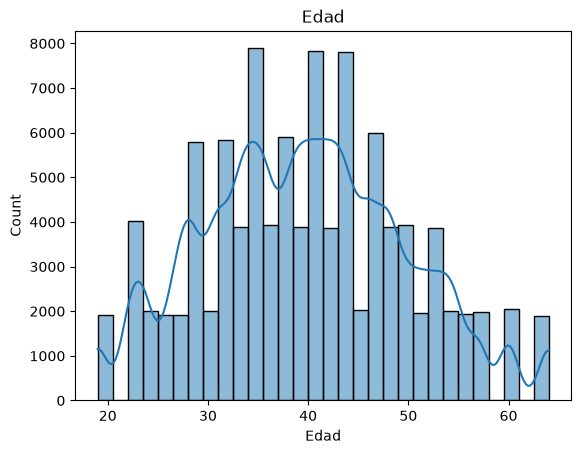

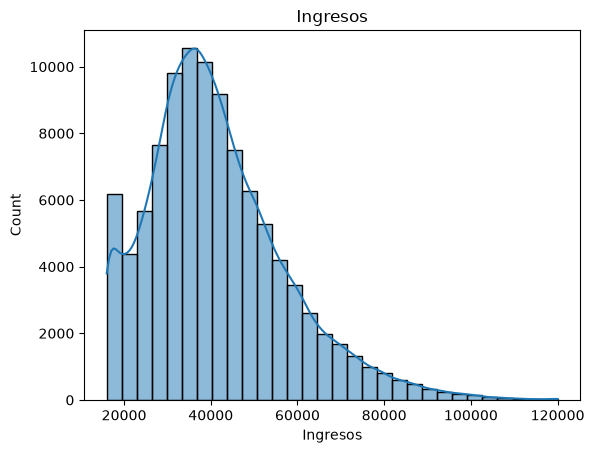

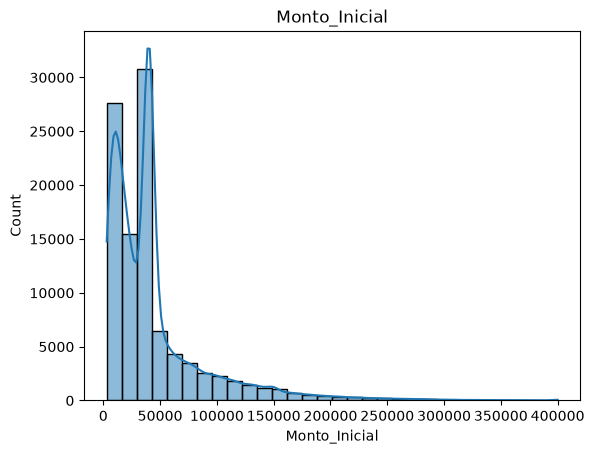

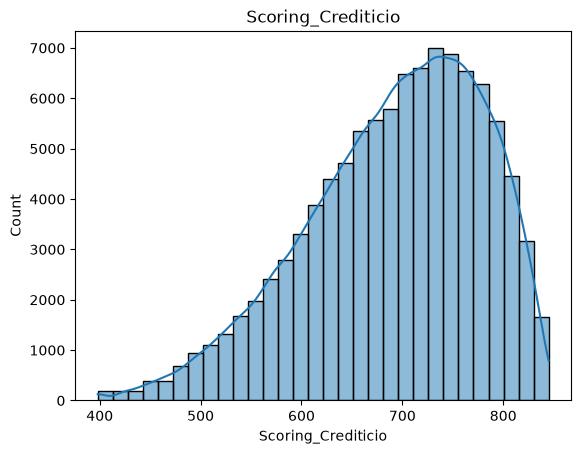

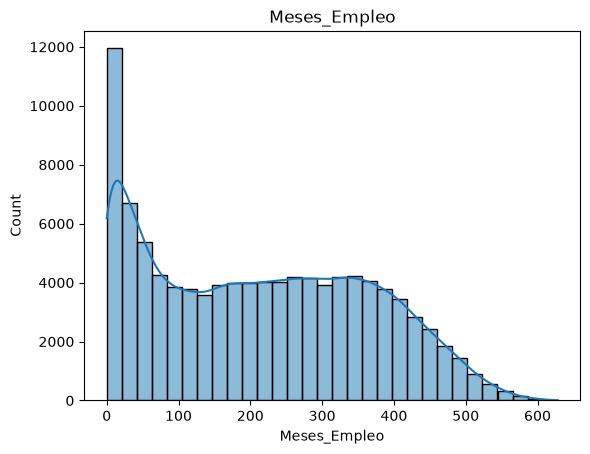

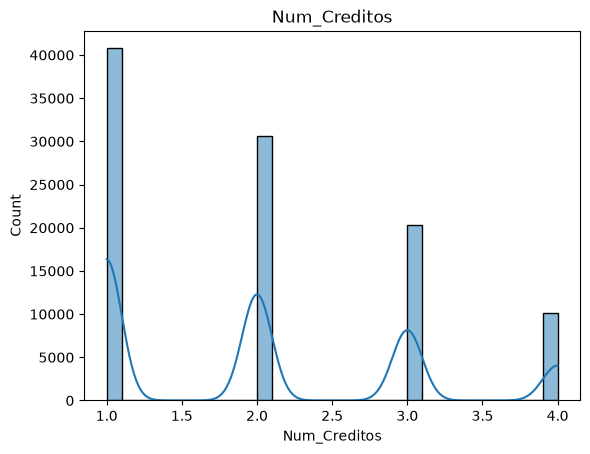

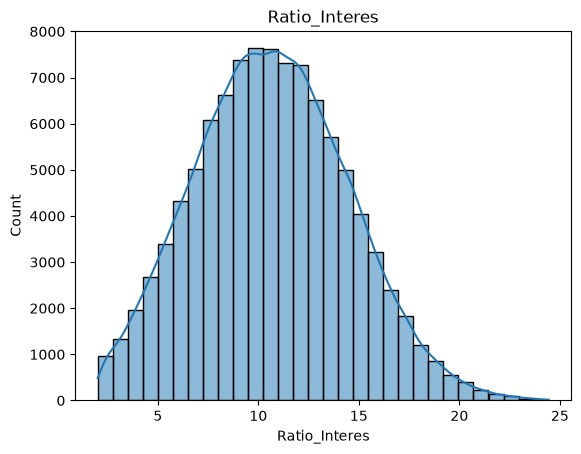

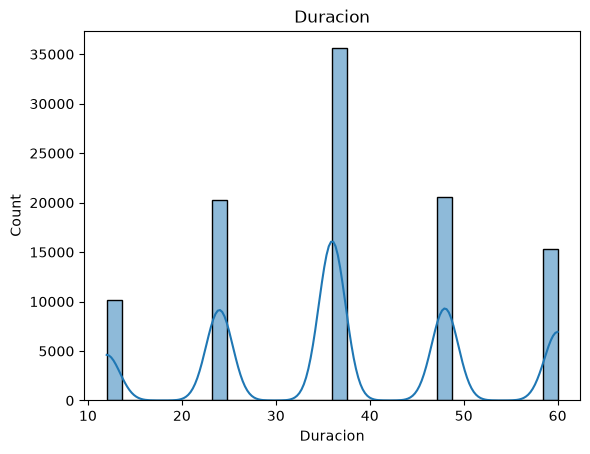

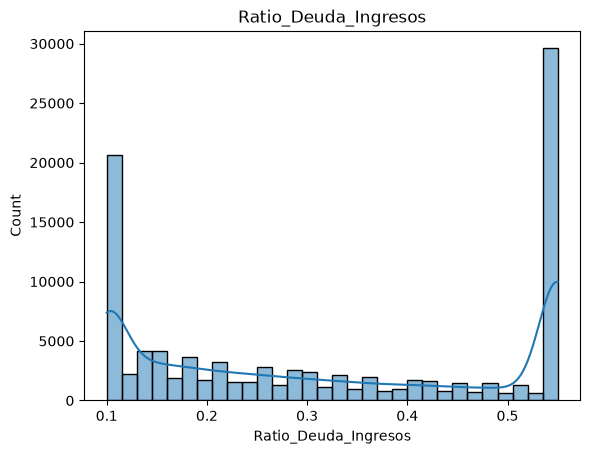

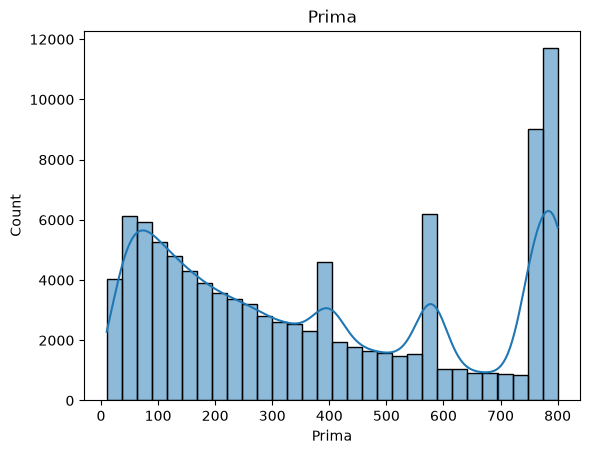

In [22]:
for col in lista_columnas:
    sns.histplot(df_total[col], kde=True, bins=30)
    plt.title(col)
    plt.show()